# 🧠 Module 2 – Session 1 Assignment
# Investigating Attention in BERT

**Course:** Generative & Agentic AI Systems

## Objective
In this assignment you will investigate how BERT distributes attention across different linguistic phenomena.

Rather than proving *how BERT thinks*, your goal is to collect evidence and make engineering observations.

---
## Learning Outcomes
After completing this notebook you should be able to:

- Build linguistic probes
- Visualize attention using BertViz
- Identify interesting attention heads
- Compare expectations with observations
- Write an engineering conclusion


# Part 0 – Environment

In [ ]:
# Uncomment if needed
# !pip install transformers bertviz torch

In [2]:
from transformers import AutoTokenizer, AutoModel
import torch

MODEL_NAME="bert-base-uncased"

tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)
model=AutoModel.from_pretrained(MODEL_NAME,output_attentions=True)
model.eval()

print("Model Loaded Successfully")

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model Loaded Successfully


In [3]:
def get_attention(sentence):
    inputs=tokenizer(sentence,return_tensors="pt")
    with torch.no_grad():
        outputs=model(**inputs)

    tokens=tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    return tokens,outputs.attentions

# Part 1 – Build Your Test Set (15 Marks)

Create **5 sentences**.

| Sentence Type | Your Sentence | Expected Attention |
|---------------|---------------|--------------------|
| Long Dependency |" The scientist who worked with the international research was promoted " |scientist was promoted |
| Ambiguous Pronoun |" The manager told the employee that he was late" |he manager or employee |
| Negation |" The robot did not stop when the sensor detected an obstacle" | found some relation between not and stop|
| Passive Voice | " The package was delivered by the courier " | between "package and delivered"|
| Free Choice | "Anyone can use the robot to navigate through narrow corridors." | between "Anyone  and robot" |

**Questions**

1. Why did you choose these sentences?

They allow me to investigate whether BERT attention focuses on syntactic relationships, pronouns, negation, passive constructions,

2. What do you expect BERT to focus on?
I expect BERT to focus on relationships between semantically or syntactically related tokens


# Part 2 – Run Your Experiments

In [7]:
# Replace with one of your own sentences

sentence="The scientist who worked with the international research team was promoted."

tokens,attentions=get_attention(sentence)

print(tokens)
print("Layers:",len(attentions))
print("Heads:",attentions[0].shape[1])

['[CLS]', 'the', 'scientist', 'who', 'worked', 'with', 'the', 'international', 'research', 'team', 'was', 'promoted', '.', '[SEP]']
Layers: 12
Heads: 12


In [8]:
!pip install bertviz




In [9]:
from bertviz import head_view
head_view(attentions,tokens)

<IPython.core.display.Javascript object>

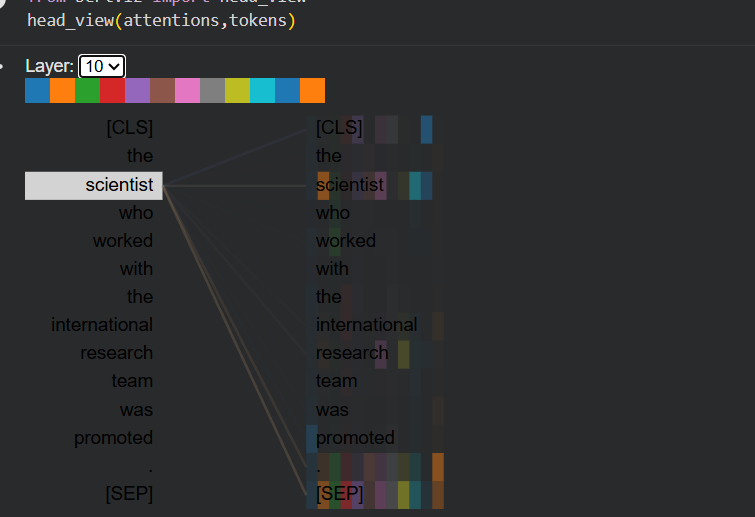

In [11]:
from bertviz import model_view
model_view(attentions,tokens)

<IPython.core.display.Javascript object>

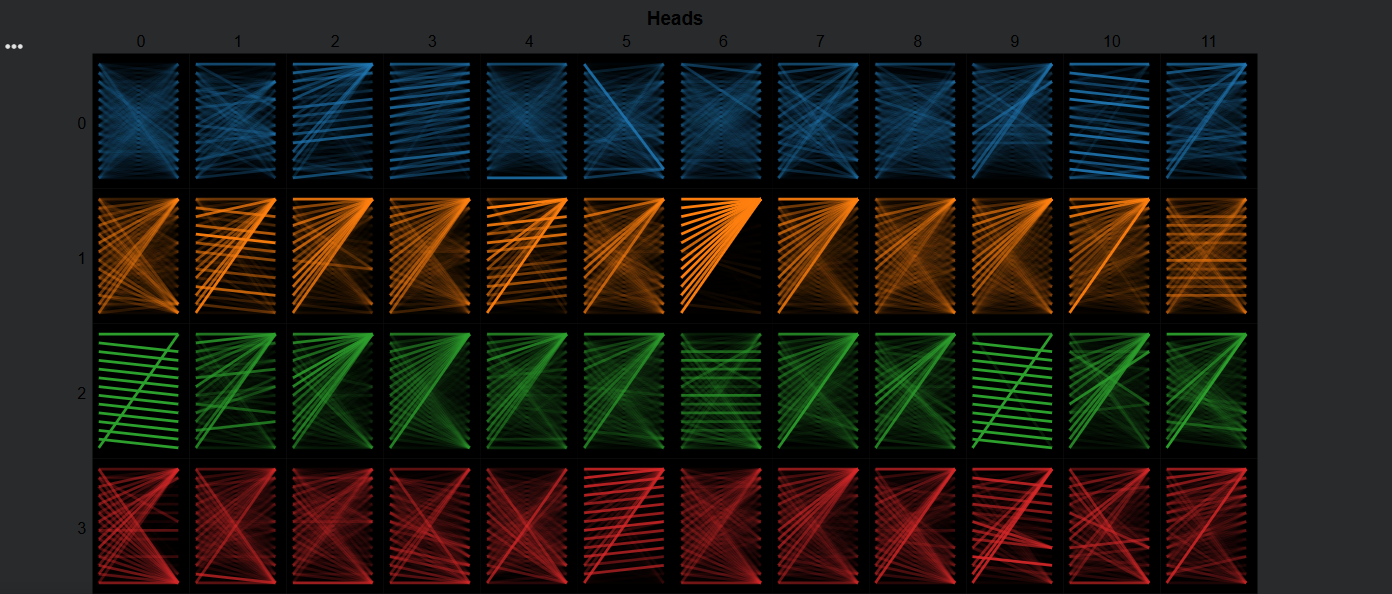

# Part 3 – Head Investigation (25 Marks)

Complete this table.

| Layer | Head | Behavior | Evidence | Did it match your expectation? |
|-------|------|----------|----------|--------------------------------|
|0 |10 | Positional |Strong attention from "worked" & "with" (0.925), which are adjacent tokens | yes |
| 4|6 | Long-range |Strong attention from "scientist" &"promoted" (0.498) despite the tokens being far apart. | yes|
| 1|6 | Special Token / CLS | Very strong attention from "scientist"& "[CLS]" (0.997).|  no|

After the table, answer:

- Why is this head interesting?

This head is interesting because it shows a relatively strong attention relationship between two distant tokens in the sentence.

- Which tokens communicate?

The tokens "scientist" and "promoted" communicate, with an attention score of 0.498 from "scientist" to "promoted".


- What engineering insight does it provide?

 some BERT attention heads can capture relationships between distant tokens. However, attention alone does not prove that the model fully understands the grammatical relationship.



In [13]:
for layer in range(len(attentions)):
    for head in range(attentions[layer].shape[1]):
        attention = attentions[layer][0][head]

        # Ignore self-attention
        attention.fill_diagonal_(0)

        max_value = attention.max()
        index = torch.argmax(attention)

        from_idx = index // attention.shape[1]
        to_idx = index % attention.shape[1]

        print(
            f"Layer {layer:2d} | Head {head:2d} | "
            f"{tokens[from_idx]} -> {tokens[to_idx]} | "
            f"Attention = {max_value:.3f}"
        )

Layer  0 | Head  0 | scientist -> team | Attention = 0.274
Layer  0 | Head  1 | international -> research | Attention = 0.379
Layer  0 | Head  2 | team -> research | Attention = 0.692
Layer  0 | Head  3 | with -> worked | Attention = 0.737
Layer  0 | Head  4 | research -> team | Attention = 0.191
Layer  0 | Head  5 | [CLS] -> . | Attention = 0.852
Layer  0 | Head  6 | [CLS] -> the | Attention = 0.433
Layer  0 | Head  7 | the -> [CLS] | Attention = 0.426
Layer  0 | Head  8 | worked -> international | Attention = 0.332
Layer  0 | Head  9 | research -> scientist | Attention = 0.599
Layer  0 | Head 10 | worked -> with | Attention = 0.925
Layer  0 | Head 11 | the -> [CLS] | Attention = 0.643
Layer  1 | Head  0 | with -> [CLS] | Attention = 0.541
Layer  1 | Head  1 | worked -> with | Attention = 0.945
Layer  1 | Head  2 | team -> [CLS] | Attention = 0.797
Layer  1 | Head  3 | . -> [CLS] | Attention = 0.655
Layer  1 | Head  4 | the -> [CLS] | Attention = 0.994
Layer  1 | Head  5 | scientist -

# Part 4 – Expectations vs Reality (15 Marks)

| Sentence | Expected | Observed | Match? |
|-----------|----------|----------|--------|
| 1 | Attention between "scientist" and "promoted".|Strong attention from "scientist" → "promoted" with a score of 0.498 in Layer 4, Head 6. | yes|
| 2 | Attention between "he" and either "manager" or "employee".|Stronger attention from "he" → "manager" (0.570) than "he" → "employee" (0.425). | partially|
| 3 |Attention between "not" and "stop". | Very strong attention from "not" → "stop" (1.000) in Layer 2, Head 9.| yes|
| 4 |Attention between "package" and "delivered". | Strong attention from "delivered" → "package" (0.898) in Layer 3, Head 10.| yes|
| 5 |Attention between "anyone" and "use" / "robot". |Stronger attention was observed from "use" → "anyone" (0.635), while "anyone" → "robot" was weaker (0.261).|partially |

Write a short discussion (100–150 words) explaining any surprising findings.

The results showed that several of our expectations were supported, but some findings were unexpected. The long-dependency probe showed attention between “scientist” and “promoted”, suggesting that at least one head captured a relationship between distant tokens. The strongest result appeared in the negation probe, where “not” attended strongly to “stop”. In the ambiguous pronoun example, “he” showed stronger attention to “manager” than “employee”, but this does not prove that BERT resolved the ambiguity correctly. The passive voice probe also showed a strong relationship between “delivered” and “package”. The free-choice example was less consistent because “use” attended strongly to “anyone”, while the relationship between “anyone” and “robot” was weaker. Overall, attention patterns were informative but did not always directly match our linguistic expectations.


In [16]:
sentences = [
    "The scientist who worked with the international research team was promoted.",
    "The manager told the employee that he was late.",
    "The robot did not stop when the sensor detected an obstacle.",
    "The package was delivered by the courier.",
    "Anyone can use the robot to navigate through narrow corridors."
]

results = []

for sentence in sentences:
    tokens, attentions = get_attention(sentence)
    results.append({
        "sentence": sentence,
        "tokens": tokens,
        "attentions": attentions
    })

print("All 5 experiments completed successfully.")

All 5 experiments completed successfully.


In [18]:
probes = [
    {
        "name": "Long Dependency",
        "sentence_id": 0,
        "pairs": [("scientist", "promoted")]
    },
    {
        "name": "Ambiguous Pronoun",
        "sentence_id": 1,
        "pairs": [("he", "manager"), ("he", "employee")]
    },
    {
        "name": "Negation",
        "sentence_id": 2,
        "pairs": [("not", "stop")]
    },
    {
        "name": "Passive Voice",
        "sentence_id": 3,
        "pairs": [("package", "delivered")]
    },
    {
        "name": "Free Choice",
        "sentence_id": 4,
        "pairs": [("anyone", "use"), ("anyone", "robot")]
    }
]

for probe in probes:
    result = results[probe["sentence_id"]]
    tokens = result["tokens"]
    attentions = result["attentions"]

    print("\n" + "=" * 60)
    print(probe["name"])

    for token_a, token_b in probe["pairs"]:

        idx_a = tokens.index(token_a)
        idx_b = tokens.index(token_b)

        best_score = 0
        best_layer = None
        best_head = None
        best_direction = None

        for layer in range(len(attentions)):
            for head in range(attentions[layer].shape[1]):

                attention = attentions[layer][0][head]

                score_ab = attention[idx_a, idx_b].item()
                score_ba = attention[idx_b, idx_a].item()

                if score_ab > best_score:
                    best_score = score_ab
                    best_layer = layer
                    best_head = head
                    best_direction = f"{token_a} -> {token_b}"

                if score_ba > best_score:
                    best_score = score_ba
                    best_layer = layer
                    best_head = head
                    best_direction = f"{token_b} -> {token_a}"

        print(
            f"{token_a} <-> {token_b}: "
            f"Best = {best_score:.3f}, "
            f"Layer {best_layer}, Head {best_head}, "
            f"Direction: {best_direction}"
        )


Long Dependency
scientist <-> promoted: Best = 0.498, Layer 4, Head 6, Direction: scientist -> promoted

Ambiguous Pronoun
he <-> manager: Best = 0.570, Layer 3, Head 10, Direction: he -> manager
he <-> employee: Best = 0.425, Layer 4, Head 10, Direction: he -> employee

Negation
not <-> stop: Best = 1.000, Layer 2, Head 9, Direction: not -> stop

Passive Voice
package <-> delivered: Best = 0.898, Layer 3, Head 10, Direction: delivered -> package

Free Choice
anyone <-> use: Best = 0.635, Layer 9, Head 4, Direction: use -> anyone
anyone <-> robot: Best = 0.261, Layer 0, Head 9, Direction: anyone -> robot


In [20]:
import pandas as pd

summary = []

for probe in probes:
    result = results[probe["sentence_id"]]
    tokens = result["tokens"]
    attentions = result["attentions"]

    for token_a, token_b in probe["pairs"]:

        idx_a = tokens.index(token_a)
        idx_b = tokens.index(token_b)

        best_score = 0
        best_layer = None
        best_head = None
        best_direction = None

        for layer in range(len(attentions)):
            for head in range(attentions[layer].shape[1]):

                attention = attentions[layer][0][head]

                score_ab = attention[idx_a, idx_b].item()
                score_ba = attention[idx_b, idx_a].item()

                if score_ab > best_score:
                    best_score = score_ab
                    best_layer = layer
                    best_head = head
                    best_direction = f"{token_a} -> {token_b}"

                if score_ba > best_score:
                    best_score = score_ba
                    best_layer = layer
                    best_head = head
                    best_direction = f"{token_b} -> {token_a}"

        summary.append([
            probe["name"],
            f"{token_a} <-> {token_b}",
            best_direction,
            round(best_score, 3),
            best_layer,
            best_head
        ])

df = pd.DataFrame(
    summary,
    columns=[
        "Phenomenon",
        "Token Pair",
        "Strongest Direction",
        "Attention Score",
        "Layer",
        "Head"
    ]
)

display(df)

,Phenomenon,Token Pair,Strongest Direction,Attention Score,Layer,Head
0,Long Dependency,scientist <-> promoted,scientist -> promoted,0.498,4,6
1,Ambiguous Pronoun,he <-> manager,he -> manager,0.570,3,10
2,Ambiguous Pronoun,he <-> employee,he -> employee,0.425,4,10
3,Negation,not <-> stop,not -> stop,1.000,2,9
4,Passive Voice,package <-> delivered,delivered -> package,0.898,3,10
5,Free Choice,anyone <-> use,use -> anyone,0.635,9,4
6,Free Choice,anyone <-> robot,anyone -> robot,0.261,0,9


# Part 5 – Engineering Reflection (20 Marks)

Imagine your manager asks:

> **Should engineers use attention maps for debugging production models?**

Yes, but attention maps should be used as a supporting debugging tool, not as a complete explanation of model behavior.

Write **300–400 words** addressing:

1. What attention maps reveal well.

 show which tokens are strongly connected to each other. They can help engineers find relationships between words and compare the behavior of different layers and attention heads.

2. Their limitations.

 do not always explain the model's reasoning. A high attention score does not necessarily mean that the model understood the relationship correctly.

3. Why attention is **not** a complete explanation.

is only one part of the Transformer model. It shows where attention is allocated, but it does not explain everything that happens inside the model or why it produces a specific prediction.

4. When engineers should use them.

Engineers should use attention maps when investigating unexpected model behavior, comparing different heads and layers, or looking for possible relationships between tokens. They should combine them with other debugging methods.

5. Your final recommendation with a confidence level.

engineers should use attention maps for debugging, but they should not rely on them alone , with high Confidence Level.

# ⭐ Bonus (+10)

Try one of the following:

- Winograd sentence
- Sarcasm
- Idiom
- Arabic sentence
- Code-mixed sentence
- Emoji sentence

Discuss whether attention changed.


In [22]:
sentence = "The trophy doesn't fit into the suitcase because it is too big."

tokens, attentions = get_attention(sentence)
print(tokens)

it_idx = tokens.index("it")
trophy_idx = tokens.index("trophy")
suitcase_idx = tokens.index("suitcase")

print("it index:", it_idx)
print("trophy index:", trophy_idx)
print("suitcase index:", suitcase_idx)
# compare between it and " trophy or suitcase "

['[CLS]', 'the', 'trophy', 'doesn', "'", 't', 'fit', 'into', 'the', 'suitcase', 'because', 'it', 'is', 'too', 'big', '.', '[SEP]']
it index: 11
trophy index: 2
suitcase index: 9


In [24]:
for layer in range(len(attentions)):
    for head in range(attentions[layer].shape[1]):

        attention = attentions[layer][0][head]

        it_to_trophy = attention[it_idx, trophy_idx].item()
        it_to_suitcase = attention[it_idx, suitcase_idx].item()

        if it_to_trophy > 0.05 or it_to_suitcase > 0.05:
            print(
                f"Layer {layer} | Head {head} | "
                f"it -> trophy: {it_to_trophy:.3f} | "
                f"it -> suitcase: {it_to_suitcase:.3f}"
            )

Layer 0 | Head 0 | it -> trophy: 0.073 | it -> suitcase: 0.049
Layer 0 | Head 1 | it -> trophy: 0.062 | it -> suitcase: 0.178
Layer 0 | Head 3 | it -> trophy: 0.001 | it -> suitcase: 0.085
Layer 0 | Head 5 | it -> trophy: 0.144 | it -> suitcase: 0.164
Layer 0 | Head 6 | it -> trophy: 0.130 | it -> suitcase: 0.123
Layer 0 | Head 8 | it -> trophy: 0.050 | it -> suitcase: 0.128
Layer 0 | Head 9 | it -> trophy: 0.085 | it -> suitcase: 0.048
Layer 0 | Head 11 | it -> trophy: 0.019 | it -> suitcase: 0.062
Layer 1 | Head 7 | it -> trophy: 0.103 | it -> suitcase: 0.064
Layer 1 | Head 8 | it -> trophy: 0.087 | it -> suitcase: 0.082
Layer 1 | Head 9 | it -> trophy: 0.058 | it -> suitcase: 0.028
Layer 2 | Head 7 | it -> trophy: 0.070 | it -> suitcase: 0.129
Layer 2 | Head 10 | it -> trophy: 0.088 | it -> suitcase: 0.160
Layer 2 | Head 11 | it -> trophy: 0.038 | it -> suitcase: 0.054
Layer 3 | Head 1 | it -> trophy: 0.114 | it -> suitcase: 0.045
Layer 3 | Head 4 | it -> trophy: 0.091 | it -> suitc

#Discussion
The attention pattern partially supports the expected interpretation of the Winograd sentence. Some heads, such as Layer 3 Head 10, strongly connected “it” with “trophy”. However, other heads focused more on “suitcase”. This shows that attention behavior varies across heads and that a single attention map is not enough to prove that BERT correctly resolved the pronoun.

##  Expectations vs Reality

| Sentence | Expected | Observed | Match? |
|-----------|----------|----------|--------|
| 1 | Attention between "scientist" and "promoted". | Strong attention from "scientist" → "promoted" with a score of 0.498 in Layer 4, Head 6. | Yes |
| 2 | Attention between "he" and either "manager" or "employee". | Stronger attention from "he" → "manager" (0.570) than "he" → "employee" (0.425). | Partially |
| 3 | Attention between "not" and "stop". | Very strong attention from "not" → "stop" (1.000) in Layer 2, Head 9. | Yes |
| 4 | Attention between "package" and "delivered". | Strong attention from "delivered" → "package" (0.898) in Layer 3, Head 10. | Yes |
| 5 | Attention between "anyone" and "use" / "robot". | Stronger attention was observed from "use" → "anyone" (0.635), while "anyone" → "robot" was weaker (0.261). | Partially |

# ✅ Submission Checklist

- [ ] Five original sentences
- [ ] Predictions written before experiments
- [ ] BertViz screenshots included
- [ ] Three head behaviors documented
- [ ] Expectations vs Reality completed
- [ ] Engineering reflection completed
- [ ] Notebook executed from start to finish
